# HOMEWORK 14

In this homework we will be working with the Fashion MNIST dataset. You will be given a classifier which suffers from considerable overfitting. Your objective will be to employ regularization techniques to mitigate the overfitting problem.

Let's start with the usual imports.

In [238]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Dropout, Flatten, Input, MaxPooling2D, BatchNormalization, RandomFlip, RandomRotation
from tensorflow.keras import Model, regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from time import time

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Set the seeds for reproducibility
from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

### Dataset

The MNIST fashgion dataset [link](https://github.com/zalandoresearch/fashion-mnist) was build by Zalando Reasearch tem consists of monochrome images of different type of clothing, namely:
* 0	T-shirt/top
* 1	Trouser
* 2	Pullover
* 3	Dress
* 4	Coat
* 5	Sandal
* 6	Shirt
* 7	Sneaker
* 8	Bag
* 9	Ankle boot

It is also one of the Keras built-in datasets. Let's load the images and quickly inspect it.

In [239]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Dataset params
num_classes = 10
size = x_train.shape[1]

print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test), 'samples')
print('Sample dims: ', x_train.shape)

Train set:    60000 samples
Test set:     10000 samples
Sample dims:  (60000, 28, 28)


Let's visualise some random samples.

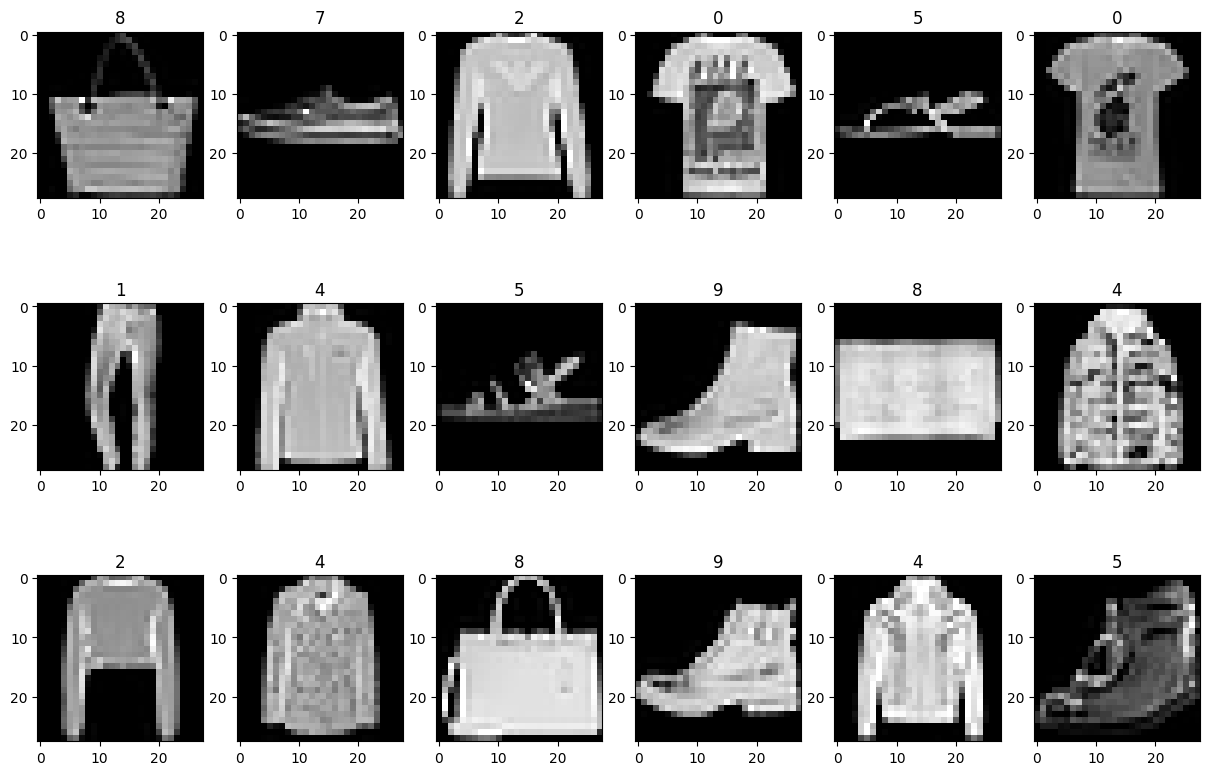

In [240]:
cnt = 1
for r in range(3):
    for c in range(6):
        idx = np.random.randint(len(x_train))
        plt.subplot(3,6,cnt)
        plt.imshow(x_train[idx, ...], cmap='gray')
        plt.title(y_train[idx])
        cnt = cnt + 1

### Building the Classifier

We are now going to build the baseline classifier that you will use throughout this homework.

In [241]:
# Data normalization
x_train = x_train/255
x_test = x_test/255

In [242]:
inputs = Input(shape=(28, 28, 1))
net = Conv2D(32, kernel_size=(3, 3), activation="relu", padding='same')(inputs)
net = Flatten()(net)
net = Dense(128)(net)
outputs = Dense(10, activation="softmax")(net)

model = Model(inputs, outputs)
model.summary()

Model: "functional_54"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_55 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_75 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_47 (Flatten)            │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_94 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_95 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,213,002 (12.26 MB)

 Trainable params: 3,213,002 (12.26 MB)

 Non-trainable params: 0 (0.00 B)

In [243]:
epochs = 50
batch_size = 64

model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
# history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(x_test, y_test))

Train Acc      0.992816686630249
Validation Acc 0.8895999789237976


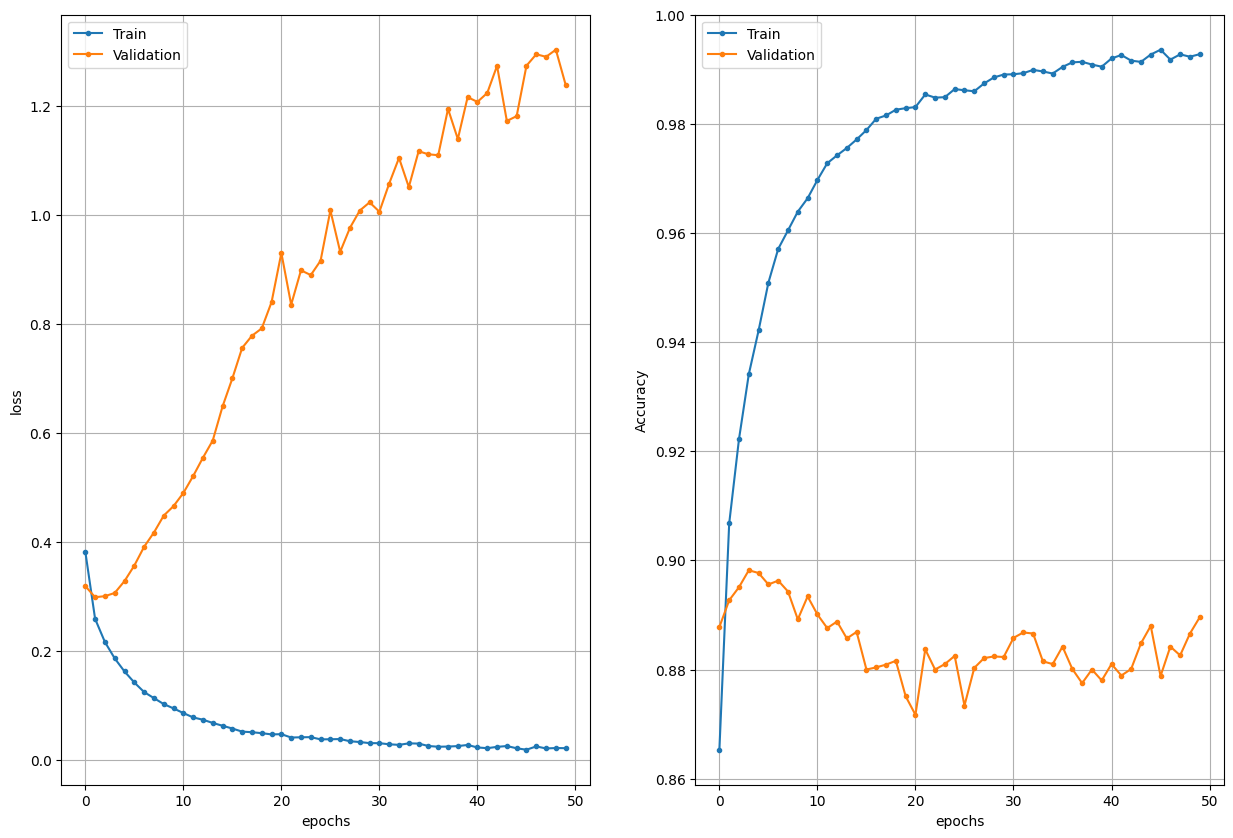

In [244]:
def plot_history(history):
    h = history.history
    epochs = range(len(h['loss']))

    plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
    plt.legend(['Train', 'Validation'])
    plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                               epochs, h['val_accuracy'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'])

    print('Train Acc     ', h['accuracy'][-1])
    print('Validation Acc', h['val_accuracy'][-1])

plot_history(history)

As you can see, the classifier suffers from massive overfitting. The validation accuracy is around 88% while the training accuracy is close to 1.

### Combat the Overfitting!

Now it is your turn. Use the classifier as a baseline, include some regularization techniques and try to improve the classification performance. You can try any techniques you might see fit, e.g.,
* Dropout
* Batch normalization
* Weight regularization
* Data augmentation
* Early stopping
* Pooling
* Reducing the number of parameters (the size of the network)
* ...

There are to objective you shall fulfill in order to successfully complete this homework:
* The validation accuracy shall be above 91%
* Your network (with all the regularizations applied) shall **not** be larger than the baseline

In [245]:
# First of all - training is incredible slow, about 35sec/epoch on v5e-1 TPU. On T4 GPU it's much faster - about 5s/epoch.
# Anyway, I decide to start with pooling to reduce number of params and increase batchsize and got about 2sec/epoch, with nearly same results.

# Next step I've tried to add dropout layer, and drop 50% neurons - validation accuracy dropped to 87%. Next I'm reduced dropout to 0.25 - 88%

# Ok, lets try BatchNormalization - no luck, 87%

# Added kernel_regularizer with 0.001 value - 89%

# Interesting, early stopper stopped after 11 epochs, so after only 4 epochs val_accuracy stopped improving after 6 epochs

# Tried it all together - 89%.

# Reduced Dropout, reduced L2 regularizer - nothing helps.

# Added additional conv2d layers from previous homework - got it worse with patience=10 :(

# Ok, lets try data augmentation - flip and rotation. Got 90.4%

# Increased L2 and droput - 90.5%

# Charts of loss and accuracy validation is very unstable. Due to lack of ideas going to ask Gemini what happens.
# Gemini recommended to decrease learning rate. Charts looks much better. Going to increase epochs - unfortunately 89%

data_augmentation = tf.keras.Sequential([
  RandomFlip("horizontal"),
  RandomRotation(0.1), # rotation in percent, o_0
], name="data_augmentation")

early_stopper = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

reg_L2 = 0.001

inputs1 = Input(shape=(28, 28, 1))
net1 = data_augmentation(inputs1)
net1 = Conv2D(32,
              kernel_size=(3, 3),
              activation="relu",
              padding='same',
              kernel_regularizer=regularizers.L2(reg_L2),
              )(net1)
net1 = Conv2D(32,
              kernel_size=(3, 3),
              activation="relu",
              padding='same',
              kernel_regularizer=regularizers.L2(reg_L2),
              )(net1)
net1 = MaxPooling2D(pool_size=(2, 2))(net1)
net1 = Conv2D(32,
              kernel_size=(3, 3),
              activation="relu",
              padding='same',
              kernel_regularizer=regularizers.L2(reg_L2),
              )(net1)
net1 = Conv2D(32,
              kernel_size=(3, 3),
              activation="relu",
              padding='same',
              kernel_regularizer=regularizers.L2(reg_L2),
              )(net1)
net1 = MaxPooling2D(pool_size=(2, 2))(net1)
net1 = Flatten()(net1)
net1 = Dense(128)(net1)
net1 = BatchNormalization()(net1)
net1 = Dropout(0.25)(net1)
outputs1 = Dense(10, activation="softmax")(net1)

model1 = Model(inputs1, outputs1)
model1.summary()

Model: "functional_56"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_56 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_76 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_77 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_78 (Conv2D)              │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_79 (Conv2D)              │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_48 (Flatten)            │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_96 (Dense)                │ (None, 128)            │       200,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_97 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 230,698 (901.16 KB)

 Trainable params: 230,442 (900.16 KB)

 Non-trainable params: 256 (1.00 KB)

In [246]:
epochs = 100
batch_size = 128

model1.compile(loss="sparse_categorical_crossentropy", optimizer=Adam(learning_rate=0.0001), metrics=["accuracy"])
history1 = model1.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(x_test, y_test), callbacks=[early_stopper])

Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6032 - loss: 1.2453 - val_accuracy: 0.7415 - val_loss: 0.9216
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7886 - loss: 0.6858 - val_accuracy: 0.8088 - val_loss: 0.6302
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8171 - loss: 0.6082 - val_accuracy: 0.8166 - val_loss: 0.5934
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8302 - loss: 0.5621 - val_accuracy: 0.8315 - val_loss: 0.5620
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8435 - loss: 0.5263 - val_accuracy: 0.8323 - val_loss: 0.5586
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8521 - loss: 0.5045 - val_accuracy: 0.8459 - val_loss: 0.5235
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8555 - loss: 0.4886 - val_accuracy: 0.8356 - val_loss: 0.5559
Epoch 8/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8584 - loss: 0.4780 -

Train Acc      0.9099166393280029
Validation Acc 0.8974999785423279


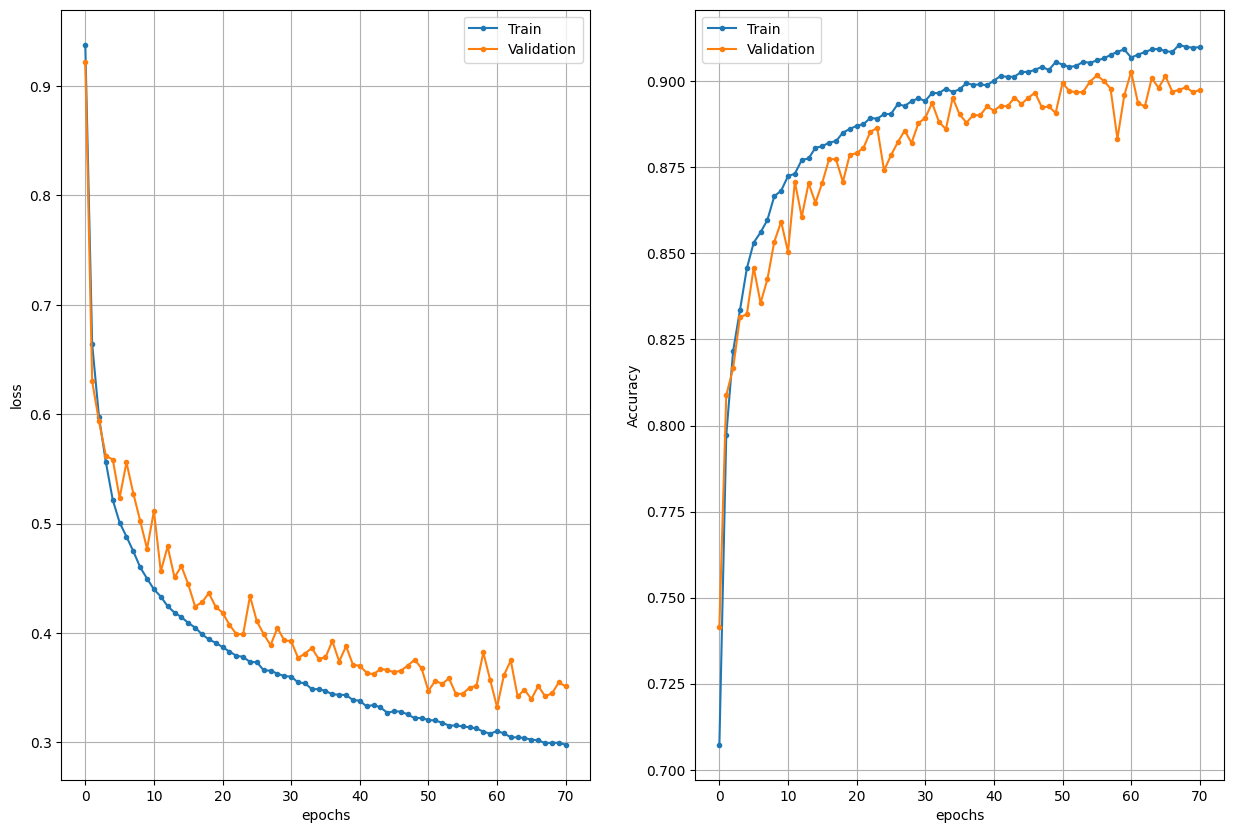

In [247]:
# Show the results

plot_history(history1)

### Questions

* What have you done in order to improve the performance?
* Have you tried configurations that did not work out?

My steps are commented above, with ups and downs. Sadly, I did not achieve 91%, only 90.5 on previous step, but my time is up